## 三层神经网络

In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report

from homemade.utils.hypothesis import sigmoid


class ThreeNeuralNetwork:
    def __init__(self, input_size, layer1_size, layer2_size, output_size):
        self.input_size = input_size
        self.layer1_size = layer1_size
        self.layer2_size = layer2_size
        self.output_size = output_size
        self.lr = 0.01

        self.w1 = np.random.randn(self.input_size, self.layer1_size) * np.sqrt(2 / self.input_size)
        self.w2 = np.random.randn(self.layer1_size, self.layer2_size) * np.sqrt(2 / self.layer1_size)
        self.w3 = np.random.randn(self.layer2_size, self.output_size) * np.sqrt(2 / self.layer2_size)

        self.b1 = np.zeros((1, self.layer1_size))
        self.b2 = np.zeros((1, self.layer2_size))
        self.b3 = np.zeros((1, self.output_size))

    def sigmoid(self, x):
        pos_mask = x >= 0
        neg_mask = ~pos_mask
        z = np.zeros_like(x, dtype=float)

        z[pos_mask] = 1 / (1 + np.exp(-x[pos_mask]))
        z[neg_mask] = np.exp(x[neg_mask]) / (1 + np.exp(x[neg_mask]))
        return z

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def fit(self, x, y, max_iter=1000):
        if x.shape[1] != self.input_size:
            raise ValueError("Input dimension does not match with input size")

        cost_history = []
        for _ in range(max_iter):
            y_pred, cache = self.forword(x)

            m = y.shape[0]
            # 将整数标签转换为独热编码，以便与损失函数兼容
            y_one_hot = np.zeros((m, self.output_size))
            y_one_hot[np.arange(m), y.flatten()] = 1

            cost = self.multi_class_binary_cross_entropy(y_one_hot, y_pred)
            self.backword(x, cache, y_one_hot)
            cost_history.append(cost)

        return cost_history

    def multi_class_binary_cross_entropy(self, y_true_one_hot, y_pred):
        m = y_true_one_hot.shape[0]
        eps = 1e-9
        # 对每个类别计算二元交叉熵损失并求平均
        loss = -np.mean(y_true_one_hot * np.log(y_pred + eps) + (1 - y_true_one_hot) * np.log(1 - y_pred + eps))
        return loss

    def predict(self, x):
        y_pred_prob, _ = self.forword(x)
        # 找到概率最高的类别索引
        return np.argmax(y_pred_prob, axis=1).reshape(-1, 1)

    def forword(self, x):
        z1 = np.dot(x, self.w1) + self.b1
        a1 = self.sigmoid(z1)

        z2 = np.dot(a1, self.w2) + self.b2
        a2 = self.sigmoid(z2)

        z3 = np.dot(a2, self.w3) + self.b3
        a3 = self.sigmoid(z3)

        cache = {
            'a1': a1, 'a2': a2, 'a3': a3,
            'z1': z1, 'z2': z2, 'z3': z3,
        }
        return a3, cache

    def backword(self, x, cache, y_one_hot):
        m = x.shape[0]
        a1, a2, a3 = cache['a1'], cache['a2'], cache['a3']

        # 梯度计算与Softmax+多元交叉熵类似
        dz3 = a3 - y_one_hot

        dw3 = np.dot(a2.T, dz3) / m
        db3 = np.sum(dz3, axis=0, keepdims=True) / m

        dz2 = np.dot(dz3, self.w3.T) * self.sigmoid_derivative(a2)
        dw2 = np.dot(a1.T, dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        dz1 = np.dot(dz2, self.w2.T) * self.sigmoid_derivative(a1)
        dw1 = np.dot(x.T, dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        self.w3 -= self.lr * dw3
        self.b3 -= self.lr * db3
        self.w2 -= self.lr * dw2
        self.b2 -= self.lr * db2
        self.w1 -= self.lr * dw1
        self.b1 -= self.lr * db1


你这个代码里确实写了一个“三层神经网络”，但是要注意它实际上是**二元交叉熵的写法**，所以严格意义上默认是二分类的。但为什么它看起来也能做多分类呢？核心原因在于这几个点：

---

### 1. 输出层的结构

```python
self.w3 = np.random.randn(self.layer2_size, self.output_size) * np.sqrt(1 / self.layer2_size)
self.b3 = np.random.randn(1, self.output_size)
```

这里 `output_size` 是可配置的，如果你设定为 **2**，那输出层就是 `(m, 2)`，即每个样本对应两个输出神经元。

* 如果 `output_size=1`，就是二分类概率（sigmoid 输出）。
* 如果 `output_size=k`，每个样本会得到 `k` 个 sigmoid 值，形如 `[0.2, 0.9, 0.1]`。

所以它本质上是「多标签分类」的写法，而不是标准的「多分类」。

---

### 2. 损失函数的问题

你写的是 **二元交叉熵**：

```python
loss = -np.mean(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))
```

这个公式对每个输出维度都独立计算交叉熵。

* 如果 `y` 是 `(m, 2)` 的 one-hot，比如 `[1,0]`、`[0,1]`，那它也能工作。
* 但这不是严格意义上的 **softmax + 多分类交叉熵**，而是多个二分类交叉熵拼起来。

这种方式其实等价于「每个类别独立的二分类」，所以能拟合 one-hot 的多分类。

---

### 3. 为啥还能跑出多分类的效果？

* `a3 = sigmoid(z3)` 给出多个维度的概率（但它们不一定加和为 1）。
* 如果你的 `y` 是 one-hot，那么最小化 BCE 就会推动正确类别靠近 1，错误类别靠近 0。
* 在预测时 `(y_pred > threshold).astype(int)`，理论上可能会输出多个 1，但如果训练充分，每一行基本只有一个类别接近 1，其他都接近 0，所以就像在做多分类。

---

### 4. 正统做法（softmax + 多分类交叉熵）

如果你想写**真正的多分类**，最后一层应该是 softmax：

```python
def softmax(self, x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))  # 数值稳定
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)
```

然后损失函数改为：

```python
def categorical_cross_entropy(self, y_true, y_pred):
    eps = 1e-9
    return -np.mean(np.sum(y_true * np.log(y_pred + eps), axis=1))
```

这样输出就是标准的概率分布（每行加和为 1），才能称为**多分类**。

---

✅ 总结：
你的网络能“预测多分类”，是因为：

* 输出层神经元数 > 1
* 使用了逐维二元交叉熵，配合 one-hot 标签，也能逼近多分类的效果

但这实际上是 **多标签二分类的形式**。如果要做真正的多分类，应该改成 **softmax + 多分类交叉熵**。

---

要不要我帮你把你的这份代码改成 **softmax + 多分类交叉熵版**，你就能直接跑 CIFAR10、MNIST 这种多分类了？


正在下载 MNIST 数据集...
MNIST 数据集下载完成！

数据集形状 (X): (70000, 784)
标签形状 (y): (70000,)

部分标签: [5 0 4 1 9 2 1 3 1 4]


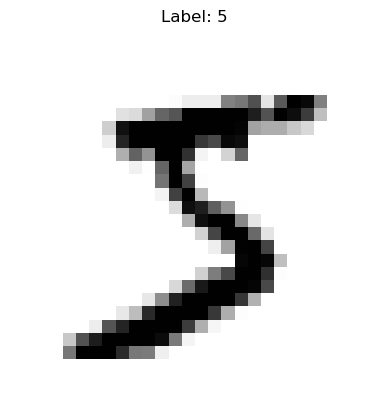

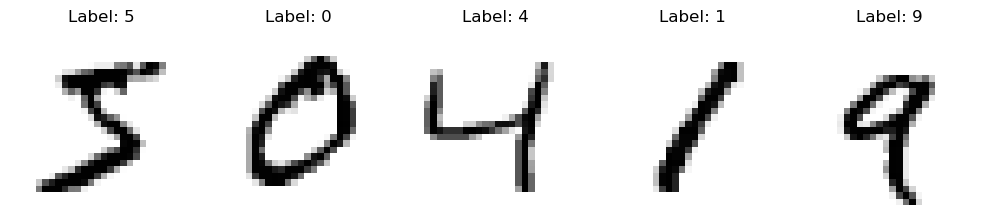

In [10]:
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import numpy as np

# 获取 MNIST 数据集
# version='7' 是 MNIST 的一个常用版本。
# as_frame=False 表示返回 NumPy 数组而不是 Pandas DataFrame，这在大多数机器学习任务中更常用。
print("正在下载 MNIST 数据集...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
print("MNIST 数据集下载完成！")

# 数据集对象是一个Bunch（字典类似的对象），包含以下键：
# 'data': 包含图像像素数据的二维数组 (n_samples, n_features)
# 'target': 包含对应标签的一维数组 (n_samples,)
X, y = mnist.data, mnist.target

print(f"\n数据集形状 (X): {X.shape}") # 70000张图片，每张图片784个像素 (28*28)
print(f"标签形状 (y): {y.shape}")   # 70000个标签

# MNIST 标签通常是字符串类型，可以将其转换为整数
y = y.astype(np.uint8)

# 查看一些样本
print(f"\n部分标签: {y[:10]}")

# 可视化第一张图片
some_digit = X[0]
some_digit_image = some_digit.reshape(28, 28)

plt.imshow(some_digit_image, cmap=plt.cm.binary)
plt.title(f"Label: {y[0]}")
plt.axis("off")
plt.show()

# 示例：查看不同数字的图片
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X[i].reshape(28, 28), cmap=plt.cm.binary)
    plt.title(f"Label: {y[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [11]:
X.shape, y.shape

((70000, 784), (70000,))

正在下载 MNIST 数据集...
MNIST 数据集下载完成！

数据集形状 (X): (70000, 784)
标签形状 (y): (70000,)

开始训练模型...
模型训练完成。


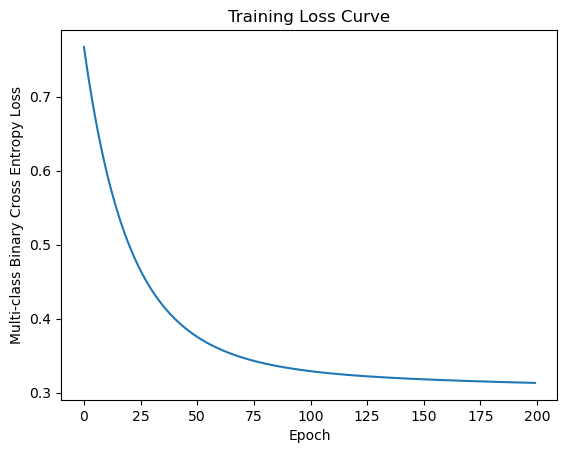


模型在测试集上的准确率: 0.3530

分类报告:
              precision    recall  f1-score   support

           0       0.89      0.39      0.54      2778
           1       0.28      0.98      0.44      3159
           2       0.46      0.12      0.19      2806
           3       0.23      0.53      0.32      2829
           4       0.40      0.21      0.28      2648
           5       0.10      0.00      0.00      2544
           6       0.44      0.17      0.24      2766
           7       0.51      0.35      0.42      2985
           8       0.68      0.28      0.40      2665
           9       0.35      0.37      0.36      2820

    accuracy                           0.35     28000
   macro avg       0.43      0.34      0.32     28000
weighted avg       0.43      0.35      0.32     28000



In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# --- 主脚本开始 ---

print("正在下载 MNIST 数据集...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
print("MNIST 数据集下载完成！")

X, y = mnist.data, mnist.target
print(f"\n数据集形状 (X): {X.shape}")
print(f"标签形状 (y): {y.shape}")

y = y.astype(np.uint8)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

network = ThreeNeuralNetwork(784, 64, 32, 10)

print("\n开始训练模型...")
cost_history = network.fit(X_train_scaled, y_train, max_iter=200)
print("模型训练完成。")

plt.plot(cost_history)
plt.xlabel('Epoch')
plt.ylabel('Multi-class Binary Cross Entropy Loss')
plt.title('Training Loss Curve')
plt.show()

y_pred = network.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred.flatten())
print(f"\n模型在测试集上的准确率: {acc:.4f}")
print("\n分类报告:")
print(classification_report(y_test, y_pred))

In [13]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000)
mlp.fit(X_train_scaled, y_train)
y_pred = mlp.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred.flatten())
y_test[10:], y_pred[10:]

(array([3, 9, 9, ..., 6, 2, 7], dtype=uint8),
 array([3, 9, 9, ..., 6, 2, 7], dtype=uint8))

In [41]:
y_pred[10:]

array([3, 9, 9, ..., 6, 3, 7], dtype=uint8)

In [70]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(80, 80))  # Set figure size
rows, cols = 10, 10  # 4 images in a vertical stack

for i in range(rows * cols):
    plt.subplot(rows, cols, i + 1)  # Create subplot for each image
    index = np.random.choice(len(X_test_scaled), size=1)[0]  # Get a single random index
    x_test_scaled_sample = X_test_scaled[index:index+1]  # Ensure proper slicing
    y_pred_sample = mlp.predict(x_test_scaled_sample)[0]  # Get prediction for single sample
    if y_pred_sample == y_test[index]:
        plt.imshow(X_test[index].reshape(28, 28), cmap='gray')  # Use grayscale for digit images
    else:
        plt.imshow(X_test[index].reshape(28, 28), cmap='viridis')
    plt.axis("off")  # Turn off axes for cleaner display

plt.tight_layout()  # Adjust spacing between subplots
plt.show()



# 多层神经网络(自定义实现)
* 不指定输入层的特征数,
* 不指定输出层的分类数
* 不指定隐藏层数
* 采用sigmoid作为隐藏层的非线性变换
* softmax作为最终分类结果输出

In [55]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn.preprocessing import OneHotEncoder

class NeuralNetwork:
    def __init__(self, hidden_layer_sizes, learning_rate=0.01):
        if len(hidden_layer_sizes) < 1 and hidden_layer_sizes[0] < 0:
            raise ValueError("Neural Network needs at least one hidden layer size")
        self.hidden_layer_sizes = np.array(hidden_layer_sizes)
        self.weights = [] # w0, w1, w2
        self.biases = [] # b0, b1, b2
        self.X = None
        self.y = None
        self.learning_rate = learning_rate
        self.feature_num = None
        self.class_num = None

    def train(self, X, y, max_iter=50, batch_size=1024):
        self.X = X
        self.y = y
        if X.ndim != 2:
            raise ValueError("X.ndim must be 2")
        unique_values = np.unique(y)
        self.feature_num = X.shape[1]
        self.class_num = len(unique_values)
        self.weights, self.biases = NeuralNetwork.init_weights_and_biases(self.feature_num, self.hidden_layer_sizes, self.class_num)

        cost_history = []
        n_samples = X.shape[0]
        for epoch in range(max_iter):
            # 随机打乱
            indices = np.random.permutation(n_samples)
            X_shuffled, y_shuffled = X[indices], y[indices]

            epoch_cost = 0
            for i in range(0, n_samples, batch_size):
                X_batch = X_shuffled[i:i+batch_size]
                y_batch = y_shuffled[i:i+batch_size]
                # 前向传播 + 反向传播 + 参数更新
                batch_cost = self.update(X_batch, y_batch)
                epoch_cost += batch_cost
            cost_history.append((epoch_cost / (n_samples // batch_size)))
            print(f"Epoch {epoch+1}/{max_iter}, Loss={cost_history[-1]:.4f}")
        return cost_history

    def update(self, X_batch, y_batch):
        y_batch_pred, cache = self.forward(self.weights, self.biases, X_batch)
        batch_cost = self.categorical_cross_entropy(y_batch_pred, y_batch)
        self.backward(X_batch, y_batch, cache, self.learning_rate)
        return batch_cost

    def categorical_cross_entropy(self, y_pred, y_true):
        ## softmax + cce
        ## 不转出独热编码
        ## 取出正确标签位置所在的概率值
        y_pred_probs = y_pred[range(len(y_pred)), y_true]
        return -np.mean(np.log(y_pred_probs + 1e-9))

    def predict(self, X):
        y_pred, _ = self.forward(self.weights, self.biases, X)
        return np.argmax(y_pred, axis=1)

    def forward(self, weights, biases, X):
        A_cache = []
        A_cache.append(X)
        A = X
        for index, (weight, bias) in enumerate(zip(weights, biases)):
            Z = np.dot(A, weight) + bias  # (batch_size, n_l)
            if index == len(weights) - 1:  # 最后一层
                A = self.softmax(Z)
            else:
                A = self.sigmoid(Z)
            A_cache.append(A)

        return A, A_cache

    def backward(self, X, y, cache, lr):
        samples = len(X)
        A = cache ## [X, A1, A2, ..., An-1, An]
        n = len(A) - 1
        dW = []
        db = []
        y_onehot = OneHotEncoder(categories=[np.arange(10)], sparse_output=False).fit_transform(y.reshape(-1, 1))
        dZ = A[n] - y_onehot   ## (m, C) m样本数  C类别个数  记住权重不带样本数, 权重只带神经元个数
        dW.append(A[n-1].T @ dZ / samples) ## A是带样本数的--每个样本每一层(a个神经元)的结果, (m, a).T @ (m, C) = (a, C)
        db.append(dZ.sum(axis=0, keepdims=True) / samples)  ## (C, )

        delta = dZ
        weight_pos = len(self.weights) - 1
        for i in range(1, n):
            delta =  (delta @ self.weights[weight_pos - i + 1].T) * (A[n - i] * (1 - A[n - i])) ## 这里是点乘, 如果i-1层有b个神经元(m, b) 点乘后,矩阵还是(m, b)
            dW.append(A[n - i -1].T @ delta / samples)
            db.append(delta.sum(axis=0, keepdims=True) / samples)

        dW = dW[::-1]
        db = db[::-1]
        for i in range(len(self.weights)):
            self.weights[i] = self.weights[i] - lr * dW[i]
            self.biases[i] = self.biases[i] - lr * db[i]

    @staticmethod
    def init_weights_and_biases(feature_num, hidden_layer_sizes, class_num):
        layer_sizes = np.hstack(([feature_num], hidden_layer_sizes, [class_num]))
        weights = [NeuralNetwork.random_weight(layer_sizes[i], layer_sizes[ i +1]) for i in range(len(layer_sizes ) -1)]
        biases = [NeuralNetwork.random_bias(layer_sizes[j +1]) for j in range(len(layer_sizes ) -1)]
        return weights, biases

    @staticmethod
    def random_weight(start, end):
        return np.random.randn(start, end) * np.sqrt(1 / start)

    @staticmethod
    def random_bias(num):
        return np.zeros((1, num))

    def sigmoid(self, x):
        pos_mask = x >= 0
        neg_mask = ~pos_mask
        z = np.zeros_like(x, dtype=float)

        z[pos_mask] = 1 / (1 + np.exp(-x[pos_mask]))
        z[neg_mask] = np.exp(x[neg_mask]) / (1 + np.exp(x[neg_mask]))
        return z

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def softmax(self, x):
        e_x = np.exp(x - np.max(x, axis=1, keepdims=True))  # 防止溢出
        return e_x / np.sum(e_x, axis=1, keepdims=True)



In [112]:
from sklearn.preprocessing import StandardScaler
print("正在下载 MNIST 数据集...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
print("MNIST 数据集下载完成！")

X, y = mnist.data, mnist.target
print(f"\n数据集形状 (X): {X.shape}")
print(f"标签形状 (y): {y.shape}")

y = y.astype(np.uint8)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


正在下载 MNIST 数据集...
MNIST 数据集下载完成！

数据集形状 (X): (70000, 784)
标签形状 (y): (70000,)


In [77]:
from sklearn.metrics import classification_report
y_test_pred = nn.predict(X_test_scaled)
print(classification_report(y_test, y_test_pred))


              precision    recall  f1-score   support

           0       0.96      0.97      0.96      2778
           1       0.95      0.97      0.96      3159
           2       0.93      0.92      0.93      2806
           3       0.92      0.92      0.92      2829
           4       0.93      0.94      0.94      2648
           5       0.91      0.91      0.91      2544
           6       0.95      0.97      0.96      2766
           7       0.93      0.94      0.94      2985
           8       0.92      0.89      0.91      2665
           9       0.93      0.92      0.92      2820

    accuracy                           0.94     28000
   macro avg       0.94      0.93      0.94     28000
weighted avg       0.94      0.94      0.94     28000



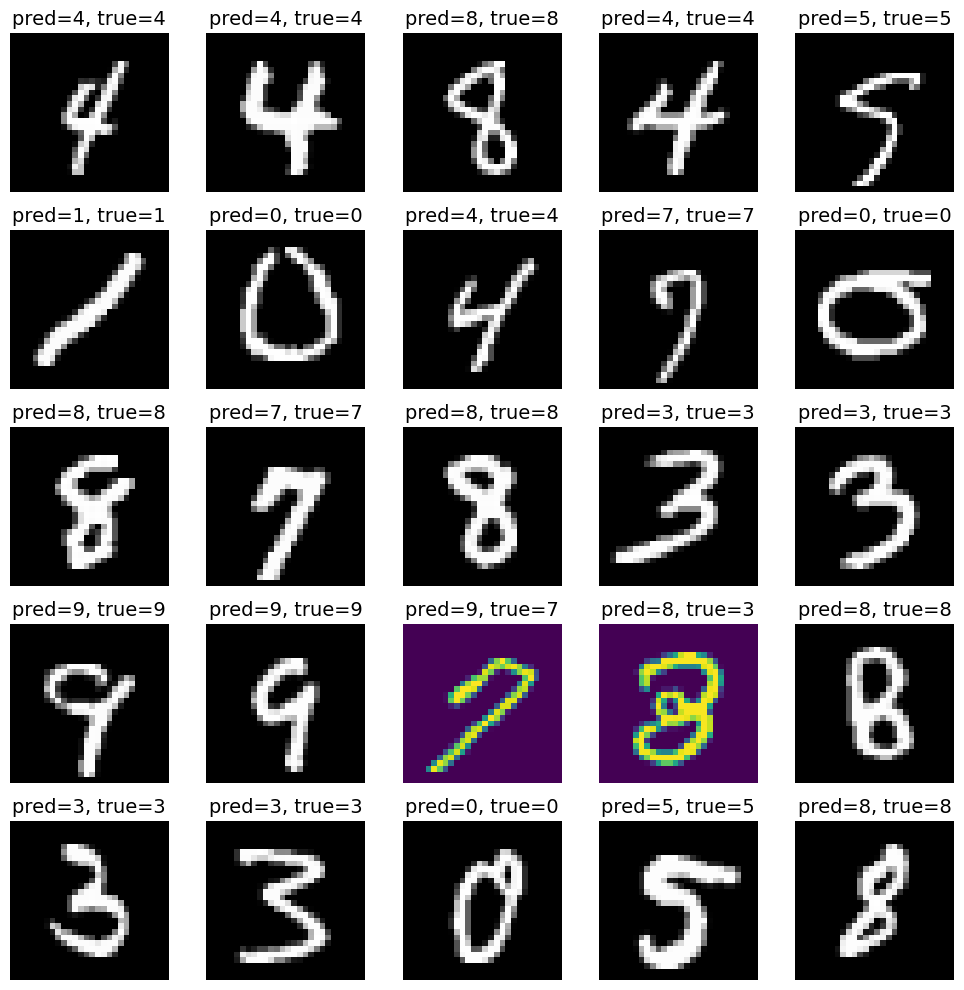

0.92


In [104]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 10))  # Set figure size
rows, cols = 5, 5  # 4 images in a vertical stack

err = 0
ok = 0
for i in range(rows * cols):
    plt.subplot(rows, cols, i + 1)  # Create subplot for each image
    index = np.random.choice(len(X_test_scaled), size=1)[0]  # Get a single random index
    x_test_scaled_sample = X_test_scaled[index:index+1]  # Ensure proper slicing
    y_pred_sample = nn.predict(x_test_scaled_sample)[0]  # Get prediction for single sample
    if y_pred_sample == y_test[index]:
        ok += 1
        plt.imshow(X_test[index].reshape(28, 28), cmap='gray')  # Use grayscale for digit images
    else:
        err += 1
        plt.imshow(X_test[index].reshape(28, 28), cmap='viridis')
    plt.title(f"pred={y_pred_sample}, true={y_test[index]}", fontsize=14)
    plt.axis("off")  # Turn off axes for cleaner display
    plt.subplots_adjust(wspace=0.5, hspace=0.5)
    plt.tight_layout()
plt.show()

print(ok / (ok + err))


# 结构化版本的神经网络

In [148]:
print("正在下载 MNIST 数据集...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
print("MNIST 数据集下载完成！")

X, y = mnist.data, mnist.target
print(f"\n数据集形状 (X): {X.shape}")
print(f"标签形状 (y): {y.shape}")

y = y.astype(np.uint8)
y_one_hot = np.zeros((len(y), 10))
y_one_hot[np.arange(len(y)), y] = 1

X_train, X_test, y_train, y_test = train_test_split(X, y_one_hot, test_size=0.4, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

正在下载 MNIST 数据集...
MNIST 数据集下载完成！

数据集形状 (X): (70000, 784)
标签形状 (y): (70000,)


正在下载 MNIST 数据集...
MNIST 数据集下载完成！

数据集形状 (X): (70000, 784)
标签形状 (y): (70000,)

--- 正在开始训练 ---
Epoch 10, Loss: 0.1756
Epoch 20, Loss: 0.1218
Epoch 30, Loss: 0.0943
Epoch 40, Loss: 0.0758
Epoch 50, Loss: 0.0622
Epoch 60, Loss: 0.0519
Epoch 70, Loss: 0.0445
Epoch 80, Loss: 0.0363
Epoch 90, Loss: 0.0306
Epoch 100, Loss: 0.0260
Epoch 110, Loss: 0.0218
Epoch 120, Loss: 0.0187
Epoch 130, Loss: 0.0161
Epoch 140, Loss: 0.0135
Epoch 150, Loss: 0.0114
Epoch 160, Loss: 0.0096
Epoch 170, Loss: 0.0082
Epoch 180, Loss: 0.0070
Epoch 190, Loss: 0.0060
Epoch 200, Loss: 0.0053


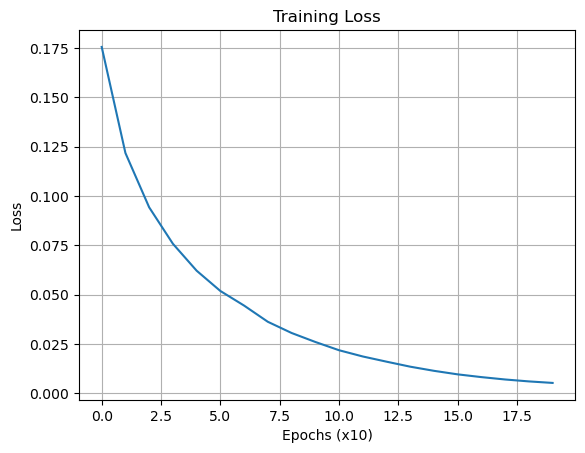


--- 正在评估模型性能 ---
模型在测试集上的准确率: 95.24%


In [1]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler

class Utils:
    """
    包含各种激活函数和其导数的静态类。
    """
    @staticmethod
    def sigmoid(z):
        """Sigmoid 激活函数。"""
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    @staticmethod
    def sigmoid_derivative(a):
        """Sigmoid 激活函数的导数。"""
        return a * (1 - a)

    @staticmethod
    def relu(z):
        """ReLU (Rectified Linear Unit) 激活函数。"""
        return np.maximum(0, z)

    @staticmethod
    def relu_derivative(a):
        """ReLU 激活函数的导数。"""
        return (a > 0).astype(float)

    @staticmethod
    def softmax(z):
        """Softmax 激活函数。"""
        # 减去最大值以提高数值稳定性
        z = z - np.max(z, axis=1, keepdims=True)
        exp_scores = np.exp(z)
        return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

class Layer:
    """
    神经网络中的一层，封装了前向和反向传播的逻辑。
    """
    def __init__(self, input_size: int, output_size: int, activation: str = "relu"):
        """
        初始化层。

        参数:
        input_size (int): 输入维度。
        output_size (int): 输出维度。
        activation (str): 激活函数名称，可选 "relu", "sigmoid", "softmax"。
        """
        self.activation = activation

        # 修正：将权重矩阵形状设为 (input_size, output_size)
        if activation == "relu":
            self.W = np.random.randn(input_size, output_size) * np.sqrt(2.0 / input_size)
        else:
            self.W = np.random.randn(input_size, output_size) * 0.01
        self.b = np.zeros(output_size)

        self.A_prev = None  # 前一层的激活输出
        self.Z = None       # 线性输出
        self.A = None       # 激活后输出

    def forward(self, A_prev: np.ndarray) -> np.ndarray:
        """
        执行前向传播。
        """
        self.A_prev = A_prev
        self.Z = A_prev @ self.W + self.b

        if self.activation == "sigmoid":
            self.A = Utils.sigmoid(self.Z)
        elif self.activation == "relu":
            self.A = Utils.relu(self.Z)
        elif self.activation == "softmax":
            self.A = Utils.softmax(self.Z)
        else:
            self.A = self.Z
        return self.A

    def backward(self, dZ: np.ndarray, m: int) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        """
        执行反向传播。

        参数:
        dZ (np.ndarray): 来自后一层的梯度。
        m (int): 训练样本数。

        返回:
        tuple: (dZ_prev, dW, db)，传递给前一层的梯度、权重梯度和偏置梯度。
        """
        # 修正：dW 和 db 的计算公式
        dW = (self.A_prev.T @ dZ) / m
        db = np.sum(dZ, axis=0) / m

        # 修正：dA_prev 的计算
        dA_prev = dZ @ self.W.T

        # 根据激活函数计算传递给前一层的 dZ_prev
        if self.activation == "sigmoid":
            dZ_prev = dA_prev * Utils.sigmoid_derivative(self.A_prev)
        elif self.activation == "relu":
            dZ_prev = dA_prev * Utils.relu_derivative(self.A_prev)
        else: ## softmax已经计算过了,这里直接返回即可
            dZ_prev = dA_prev

        return dZ_prev, dW, db

    def update_gradient(self, lr: float, dW: np.ndarray, db: np.ndarray):
        """
        执行梯度下降，更新权重和偏置。
        """
        self.W = self.W - lr * dW
        self.b = self.b - lr * db


class AdvancedNeuralNetwork:
    """
    高级多层感知器，支持批量训练和更灵活的网络结构。
    """
    def __init__(self, layer_dims: list[int], activations: list[str], lr: float = 0.01):
        """
        初始化神经网络。
        """
        assert len(layer_dims) - 1 == len(activations)
        self.layers = []
        for i in range(len(activations)):
            self.layers.append(Layer(layer_dims[i], layer_dims[i+1], activations[i]))
        self.lr = lr

    def forward(self, X: np.ndarray) -> np.ndarray:
        """
        执行网络的前向传播。
        """
        A = X
        for layer in self.layers:
            A = layer.forward(A)
        return A

    def backward(self, y_hat: np.ndarray, y: np.ndarray) -> list[tuple[np.ndarray, np.ndarray]]:
        """
        执行网络的反向传播。

        参数:
        y_hat (np.ndarray): 模型的预测结果。
        y (np.ndarray): 真实标签（独热编码）。

        返回:
        list: 包含每层 (dW, db) 梯度的列表。
        """
        # Softmax 和交叉熵损失的组合梯度
        # 这也是最后一层反向传播的起点
        dZ = y_hat - y
        m = len(y)

        # 从后往前计算梯度，并存储
        grads = []
        # 处理最后一层 (Softmax)
        dZ_last, dW_last, db_last = self.layers[-1].backward(dZ, m)
        grads.append((dW_last, db_last))

        # 处理其余隐藏层
        dZ_prev = dZ_last
        for i in reversed(range(len(self.layers) - 1)):
            layer = self.layers[i]
            dZ_current, dW_current, db_current = layer.backward(dZ_prev, m)
            grads.append((dW_current, db_current))
            dZ_prev = dZ_current

        return list(reversed(grads))

    def cost_loss(self, y_hat: np.ndarray, y: np.ndarray) -> float:
        """
        计算交叉熵损失。
        """
        m = len(y_hat)
        y_hat = np.clip(y_hat, 1e-8, 1 - 1e-8)
        loss = -np.sum(y * np.log(y_hat)) / m
        return loss

    def fit(self, X: np.ndarray, y: np.ndarray, epochs: int = 1000, batch_size: int = 64, verbose: int = 100):
        """
        训练神经网络。
        """
        m = len(X)
        cost_history = []
        for epoch in range(1, epochs + 1):
            permutation = np.random.permutation(m)
            X_shuffled = X[permutation, :]
            y_shuffled = y[permutation, :]

            for i in range(0, m, batch_size):
                X_batch = X_shuffled[i:i + batch_size, :]
                y_batch = y_shuffled[i:i + batch_size, :]

                y_hat_batch = self.forward(X_batch)
                grads = self.backward(y_hat_batch, y_batch)
                self.update_params(grads)

            if epoch % verbose == 0:
                y_hat_full = self.forward(X)
                loss = self.cost_loss(y_hat_full, y)
                print(f"Epoch {epoch}, Loss: {loss:.4f}")
                cost_history.append(loss)

        return cost_history

    def update_params(self, grads: list[tuple[np.ndarray, np.ndarray]]):
        """
        根据梯度更新所有层的权重和偏置。
        """
        for layer, (dW, db) in zip(self.layers, grads):
            layer.update_gradient(self.lr, dW, db)

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        使用训练好的模型进行预测。
        """
        y_hat = self.forward(X)
        return np.argmax(y_hat, axis=1)


if __name__ == '__main__':
    print("正在下载 MNIST 数据集...")
    mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
    print("MNIST 数据集下载完成！")

    X, y = mnist.data, mnist.target
    print(f"\n数据集形状 (X): {X.shape}")
    print(f"标签形状 (y): {y.shape}")

    y = y.astype(np.uint8)
    y_one_hot = np.zeros((len(y), 10))
    y_one_hot[np.arange(len(y)), y] = 1

    X_train, X_test, y_train, y_test = train_test_split(X, y_one_hot, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    ann = AdvancedNeuralNetwork([784, 32, 16, 10], ["relu", "relu", "softmax"], lr=0.01)

    print("\n--- 正在开始训练 ---")
    cost_history = ann.fit(X_train_scaled, y_train, epochs=200, batch_size=100, verbose=10)

    plt.figure()
    plt.plot(cost_history)
    plt.xlabel('Epochs (x10)')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.grid(True)
    plt.show()

    print("\n--- 正在评估模型性能 ---")
    predictions = ann.predict(X_test_scaled)
    y_test_labels = np.argmax(y_test, axis=1)
    accuracy = np.mean(predictions == y_test_labels) * 100
    print(f"模型在测试集上的准确率: {accuracy:.2f}%")


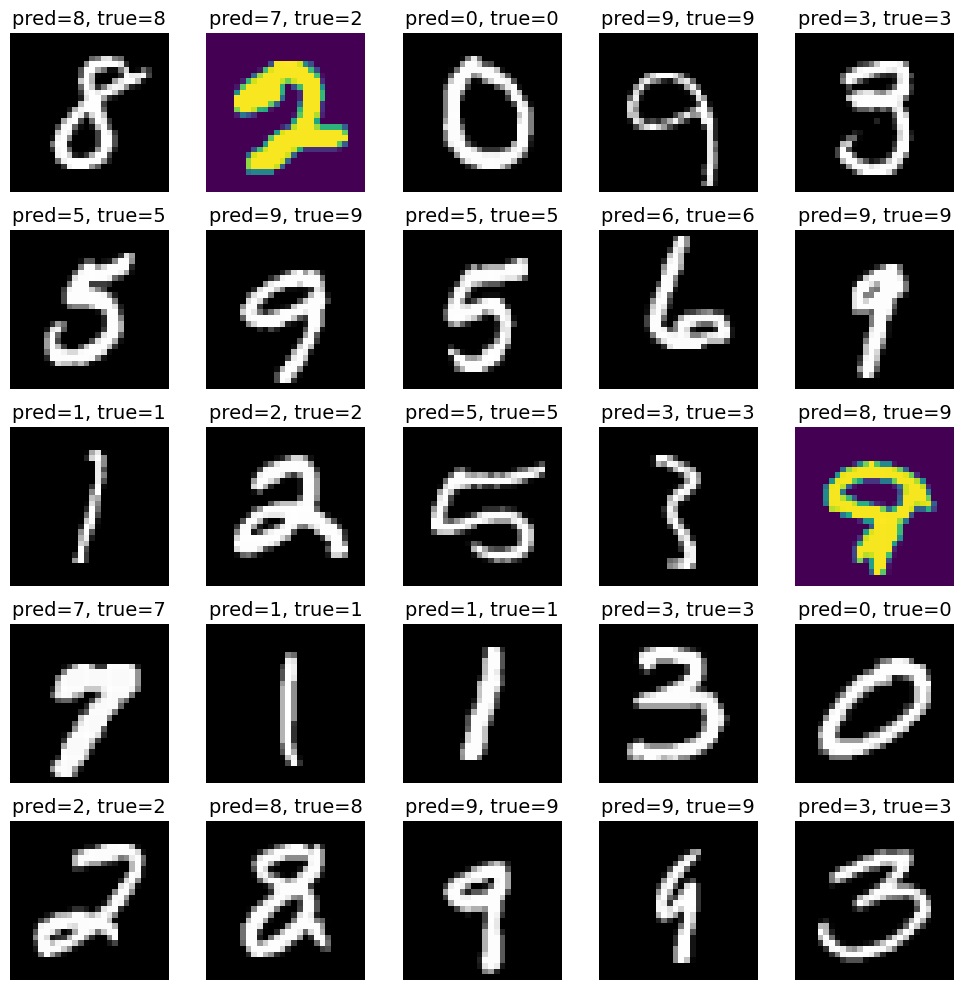

0.92


In [2]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 10))  # Set figure size
rows, cols = 5, 5  # 4 images in a vertical stack

err = 0
ok = 0
for i in range(rows * cols):
    plt.subplot(rows, cols, i + 1)  # Create subplot for each image
    index = np.random.choice(len(X_test_scaled), size=1)[0]  # Get a single random index
    x_test_scaled_sample = X_test_scaled[index:index+1]  # Ensure proper slicing
    y_pred_sample = ann.predict(x_test_scaled_sample)[0]  # Get prediction for single sample
    y_true = np.argmax(y_test[index])
    if y_pred_sample == y_true:
        ok += 1
        plt.imshow(X_test[index].reshape(28, 28), cmap='gray')  # Use grayscale for digit images
    else:
        err += 1
        plt.imshow(X_test[index].reshape(28, 28), cmap='viridis')
    plt.title(f"pred={y_pred_sample}, true={y_true}", fontsize=14)
    plt.axis("off")  # Turn off axes for cleaner display
    plt.subplots_adjust(wspace=0.5, hspace=0.5)
    plt.tight_layout()
plt.show()

print(ok / (ok + err))
